# **Colabユーザーへの注意**

# **このファイルに直接書き込まないでください—作業が消えることがあります！**

# **必ず作業前にコピーを作成してください。**

コピーの作り方

1. 左上の「File」をクリック  
> *「File」や「Runtime」などのメニューが見えないときは、右上の“v”マークを押して表示してください。*

2. 「Save a copy in Drive」を選ぶ  

3. コピーしたファイル名を「YOURNAMEs_FileName.ipynb」に変更する  
> 例：名前がOliviaなら → Olivias_FileName.ipynb  


---

* チェックマーク（✅）は保存されません。Chromeのリロードボタンでページを更新すると消えます。<br>  
途中で止めるときは、テキストセルを追加して「SO FAR DONE」など書いておいてください。

---

* Colabでは**30分〜90分ごとに以前の出力結果がリセットされます**。<br>  
そのため、`~~ is not defined`のようなエラーが**すごくよく起こります**。

🔁 `~~ is not defined`エラーが出たらどうする？

1. まず変数名のスペルを確認してください。<br>  
2. スペルが正しいのにまだエラーが出るなら、**そのセルをクリックして選択**してください。<br>  
3. 左上の「Runtime」→「Run before」をクリック。<br>  
→ これで**それまでのすべてのセルが再実行されます**。  
4. 再度、そのセルを実行してください。

もしこれでもエラーが直らなければ、<br>  
前のセルのTODOの答えに基本的なミスがあるかもしれません。<br>  
正しいかどうか確認してください。<br>  
またはChatGPTや他のコーディングアシスタントに助けを求めましょう。

**参考文献**

Sebastian Raschka 著『Build a Large Language Model From Scratch』で参照されているコードです。

コードリポジトリ: https://github.com/rasbt/LLMs-from-scratch

名著へのリンク:
[Build a Large Language Model (From Scratch)](https://www.manning.com/books/build-a-large-language-model-from-scratch)

# **Chapter 28: Instruction Tuning**

このChapterでは、Instruction Tuningを行います。<br>
前回訓練した事前学習モデルはWebサイトのデータで学習させました。<br>
膨大な知識を持ちますが、ブログ形式に近く、人間とのおしゃべりには向いていません。<br>
そこで、データを人間とのおしゃべり用のデータに差し替えて、追加で学習します。<br>
これにより、事前学習モデルを、より人間とのおしゃべりに適した形に微調整します。

|  | データ | モデル出力 |
|---|---|---|
| Pretraining | Webデータ | ブログ形式 |
| Instruction Tuning | 対話データ | 対話形式 |

## **Section 1: 事前学習モデルの読み込み**

今回もG4 GPUを使います。前回の事前学習で購入したクレジットの残りを使います。<br>
全くクレジットがない、、、！という方は、追加で100クレジットを購入してください、、、😭

**`Check Point`** <label><input type="checkbox">G4 GPUに接続したことを確認した<label>

まずは、前回訓練した事前学習モデルの重みを読み込みます。

前回と同じモデルクラスを定義し、同じconfigインスタンスを設定して、同じモデルインスタンスを作成します。

この時のモデルインスタンスのパラメータの値はランダムに初期化されています。

そして、huggingfaceのリポジトリから、チェックポイントをダウンロードします。

チェックポイントに保存されたパラメータの値を、モデルインスタンスに読み込みます。

モデルクラスは前回と同じです。

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()
        # 語彙数x埋め込み次元の埋め込みテーブルを定義する
        self.token_embedding_table = nn.Embedding(vocab_size, embedding_dim)

    def embed(self, input_indices):
        # 入力インデックスに対応する埋め込みベクトルを取得する
        return self.token_embedding_table.forward(input_indices)


class RelativePositionEmbedding(nn.Module):
    def __init__(self, num_relative_positions: int):
        super().__init__()
        self.num_relative_positions = num_relative_positions
        self.bias_embedding_table = nn.Embedding(self.num_relative_positions, 1)

    def forward(self, query_len, key_len, device_type=None):
        query_positions = torch.arange(query_len, device=device_type)[:, None]  # (query_len, 1)
        key_positions = torch.arange(key_len, device=device_type)[None, :]      # (1, key_len)
        relative_position_matrix = query_positions - key_positions # key_positions - query_positions

        # 相対距離を範囲 [0, max_distance - 1] に収める（負の距離や過大距離を切り詰め）
        # (query_len, key_len)
        clamped_relative_position_matrix = relative_position_matrix.clamp(
            min=0, max=self.num_relative_positions - 1
        )

        # 埋め込み層から対応するバイアスベクトルを取得
        # (query_len, key_len, 1)
        relative_position_bias_embeddings = self.bias_embedding_table(clamped_relative_position_matrix)

        # 最後の次元を除去して行列化
        # (query_len, key_len)
        relative_position_bias_matrix = relative_position_bias_embeddings.squeeze(-1)

        return relative_position_bias_matrix


class AttentionHead(nn.Module):
    def __init__(self, head_size, config):
        super().__init__()
        self.key_fc= nn.Linear(config.embedding_dim, head_size, bias=False)
        self.query_fc = nn.Linear(config.embedding_dim, head_size, bias=False)
        self.value_fc = nn.Linear(config.embedding_dim, head_size, bias=False)

        self.head_size = head_size
        self.relative_position_embedding_layer = RelativePositionEmbedding(num_relative_positions=config.num_relative_positions)

    def forward(self, input_tensor):
        B, T, C = input_tensor.shape  # バッチ、トークン長、埋め込みチャネル

        Key = self.key_fc.forward(input_tensor)     # (B, T, head_size)
        Query = self.query_fc.forward(input_tensor)   # (B, T, head_size)
        Value = self.value_fc.forward(input_tensor)   # (B, T, head_size)

        # Attentionスコアを計算中 (QK^T) / sqrt(embedding_dim)
        attention_weights_before_mask = Query @ Key.transpose(-2, -1) * self.head_size**(-0.5)

        # 相対位置バイアスの補正項を計算する
        relative_position_bias_matrix = self.relative_position_embedding_layer(T, T, device_type=input_tensor.device)

        # 相対位置バイアスの補正項を加算する
        attention_weights_before_mask = attention_weights_before_mask + relative_position_bias_matrix

        # マスク適用済み
        mask = torch.triu(torch.ones(T, T), diagonal=1).to(input_tensor.device)
        masked_attention_weights = attention_weights_before_mask.masked_fill(mask == 1, float('-inf'))

        # ソフトマックス → ドロップアウト → 重み付き和
        attention_weights = F.softmax(masked_attention_weights, dim=-1)

        out = attention_weights @ Value  # (B, T, head_size)
        return out


class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.num_attention_heads = config.num_attention_heads
        self.embedding_dim = config.embedding_dim
        self.head_size = int(self.embedding_dim / self.num_attention_heads)

        # ModuleListで複数のヘッドを管理する
        self.attention_heads = nn.ModuleList([
            AttentionHead(self.head_size, config)
            for _ in range(self.num_attention_heads)
        ])

        # 各ヘッドの出力を混合する線形層
        self.output_projection = nn.Linear(self.embedding_dim, self.embedding_dim)


    def forward(self, input_tensor):
        # 各ヘッドの出力を取得する
        # (B, T, head_size)のリスト
        head_outputs_list = [head.forward(input_tensor) for head in self.attention_heads]

        # 全てのヘッドの出力を連結 → (B, T, embedding_dim)
        concatenated = torch.cat(head_outputs_list, dim=-1)

        # 線形変換での出力混合
        projected = self.output_projection.forward(concatenated)

        return projected

class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.embedding_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.embedding_dim),
        )

    def forward(self, input_tensor):
        return self.net(input_tensor)

class TransformerBlock(nn.Module):
    def __init__(self, config):
        super().__init__()

        # 各LayerNormは独自のbetaとgammaを保持します。
        self.layer_norm1 = nn.LayerNorm(config.embedding_dim)
        self.layer_norm2 = nn.LayerNorm(config.embedding_dim)

        self.multihead_attention = MultiHeadAttention(config=config)
        self.feed_forward = FeedForward(config=config)

    def forward(self, input_tensor):
        # forwardメソッドは省略されています。
        normed_input = self.layer_norm1(input_tensor) # 入力にレイヤーノルムを適用する
        attention_output = self.multihead_attention(normed_input) # マルチヘッドアテンションを適用する
        residual_attention = attention_output + input_tensor # "before! layernorm1"を追加
        normed_attention = self.layer_norm2(residual_attention) # 残差出力に再度LayerNormを適用する
        feedforward_output = self.feed_forward(normed_attention) # フィードフォワードネットワークを適用する
        final_output = feedforward_output + residual_attention # "before" layernorm2 を追加する！

        return final_output

class VocabularyLogits(nn.Module):
    def __init__(self, vocab_size, config):
        super().__init__()
        # レイヤー正規化
        self.output_norm = nn.LayerNorm(config.embedding_dim)
        # 語彙数の射影
        self.vocab_projection = nn.Linear(config.embedding_dim, vocab_size)

    def forward(self, transformer_block_output):
        # Transformerブロックの出力にLayer normalizationを適用する。
        normalized_output = self.output_norm.forward(transformer_block_output)  # (B, T, C)

        # 線形層でスコアを語彙数次元に変換する。
        vocab_logits = self.vocab_projection.forward(normalized_output)  # (B, T, V)

        return vocab_logits


自分が前回、使用したクラス名を使ってください。

⚠️ 穴埋め部分あり。モデルクラスを命名してください。

In [2]:
class _______sGPT(nn.Module): # TODO: FILL
    def __init__(self, vocab_size, config):
        super().__init__()
        self.config = config  # 生成時にも使うので保持してください。
        self.token_embedding_layer = TokenEmbedding(vocab_size = vocab_size, embedding_dim = config.embedding_dim)
        self.blocks = nn.Sequential(*[TransformerBlock(config=config) for _ in range(config.layer_count)])
        self.vocab_projection = VocabularyLogits(vocab_size=vocab_size, config=config)
        self.criterion = nn.CrossEntropyLoss()

    # 尤度と損失を計算する
    def forward(self, input_indices, target_indices):
        token_embeddings = self.token_embedding_layer.embed(input_indices)
        blocks_output = self.blocks(token_embeddings)
        logits = self.vocab_projection(blocks_output)

        # 推論時はターゲットがないため、lossはNoneです
        # —確率（ロジット）のみ返されます。
        if target_indices is None:
            return logits, None

        batch_size, token_len, vocab_size = logits.shape
        logits = logits.view(batch_size * token_len, vocab_size)
        targets = target_indices.view(batch_size * token_len)
        loss = self.criterion(logits, targets)

        return logits, loss

    # テキストを生成する
    def generate(self, input_indices, max_new_tokens, temperature=1.0):
        # 指定したトークン数max_new_tokensのみ生成する
        for _ in range(max_new_tokens):
            input_conditioned = input_indices[:, -self.config.input_sequence_length:] # 入力を切り取る

            # 順伝播は `(likelihood, loss)` を返す—`likelihood` のみを `logits` として保持する。
            logits, _ = self.forward(input_conditioned, target_indices=None)
            last_logits = logits[:, -1, :] # 最後のトークンのロジットを抽出する
            last_logits = last_logits / temperature
            probs = F.softmax(last_logits, dim=-1) # Softmaxで尤度を確率に変換する

            # 次のトークンをサンプリングする
            next_token = torch.multinomial(probs, num_samples=1)

            # 新しいトークンを統合し、input_indicesを更新する。
            input_indices = torch.cat((input_indices, next_token), dim=1)

        # 最終的な`input_indices`を返す。長さは元の`input_indices`＋`max_new_tokens`
        return input_indices

Configクラスについても、前回と同じです。

In [3]:
class Config:
    # === training ===
    batch_size: int = 32 # 85GB VRAM
    total_training_steps: int = 100_000
    checkpoint_save_frequency: int = 10_000
    input_sequence_length: int = 1024

    # === model ===
    embedding_dim: int = 1280
    hidden_dim: int = 5120
    num_attention_heads: int = 10
    layer_count: int = 20
    num_relative_positions = 1024

    # === optimization ===
    max_learning_rate: float = 2e-4
    min_learning_rate: float = 2e-5
    warmup_steps: int = 1_000

    # === system ===
    device_type: str = "cuda"

In [4]:
config = Config()

モデルのインスタンスを作成します。この時、モデルのパラメータ（重みやバイアス）は、ランダムに初期化されています。

そのため、まだGPUには転送しません。GPUに転送するのは、事前学習モデルのパラメータの値を読み込んだ後です。

⚠️ 穴埋め部分あり。モデルクラスを命名してください。

In [5]:
"""DELETE
model = EveryonesGPT(vocab_size = data_loader.vocab_size, config = config).to(config.device_type) # TODO: FILL
"""
########## NEW ##########
vocab_size = 50257
# GPUにはまだ転送しない。
model = _______sGPT(vocab_size = vocab_size, config = config) # TODO: FILL
########## NEW ##########

前回同様、高速化のために、モデルに対してコンパイルという処理をします。

In [6]:
# ⚠️ Don't run this cell twice!
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision("high")
compiled_model = torch.compile(model)

現在は、モデルのパラメータ（重みやバイアス）はランダムに初期化されています。

いわば、骨組みはあるが、中身が未完な状態です。

前回の事前学習のチェックポイント`checkpoints/checkpoint_100000.pt`をダウンロードします。

次に、モデルの重みやバイアスの値`checkpoint_data["model_state_dict"]`を取得します。

そして、これを先ほどのモデルのインスタンスに読み込ませます。

HuggingFaceにログインします。

In [7]:
from huggingface_hub import login
login()

前回の事前学習のチェックポイントをダウンロードします。

In [8]:
from huggingface_hub import hf_hub_download
model_repo_id = "HayatoHongo/EveryonesGPT-checkpoints" # TODO: FILL "HayatoHongo/EveryonesGPT-checkpoints"
checkpoint_path = "checkpoints/checkpoint_010000.pt" # TODO: FILL "checkpoints/checkpoint_010000.pt"
hf_hub_download(repo_id=model_repo_id, repo_type="model", filename=checkpoint_path, local_dir=".")

checkpoints/checkpoint_010000.pt:   0%|          | 0.00/6.27G [00:00<?, ?B/s]

'checkpoints/checkpoint_010000.pt'

```python
出力: checkpoint_data（チェックポイントファイルから読み込んだ辞書。例: "model_state_dict" などを含む）
関数: torch.load
引数: checkpoint_path（読み込む .pt のパス）, map_location="cpu"（CPU上に読み込む）
```
- `checkpoint_path`で指定したチェックポイント（`.pt`）を読み込み、Pythonの辞書として受け取る。
- `checkpoint_data`を丸ごとGPU上にロードする意味はありません。なぜなら、後で`checkpoint_data`に含まれる中身`model_state_dict`だけを使いたいからです。したがって、`cpu`上にロードします。

In [9]:
checkpoint_data = torch.load(checkpoint_path, map_location="cpu")  # TODO: 出力 = 関数(引数)

```python
出力: なし
インスタンス: compiled_model（モデルのインスタンス。現在はパラメータの値はランダムに初期化されている。）
メソッド: load_state_dict
引数: THINK_BY_YOURSELF（保存済みのパラメータ辞書）
```
- チェックポイント内の `"model_state_dict"` をモデルに適用して、学習済みの重み/バイアスを復元する。

In [10]:
compiled_model.load_state_dict(checkpoint_data["model_state_dict"])  # TODO: インスタンス.メソッド(引数)

<All keys matched successfully>

モデルのインスタンスに、事前学習モデルのパラメータの値を読み込むことができました。

これをGPU上に転送します。

In [11]:
compiled_model.to("cuda")

OptimizedModule(
  (_orig_mod): _______sGPT(
    (token_embedding_layer): TokenEmbedding(
      (token_embedding_table): Embedding(50257, 1280)
    )
    (blocks): Sequential(
      (0): TransformerBlock(
        (layer_norm1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (layer_norm2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (multihead_attention): MultiHeadAttention(
          (attention_heads): ModuleList(
            (0-9): 10 x AttentionHead(
              (key_fc): Linear(in_features=1280, out_features=128, bias=False)
              (query_fc): Linear(in_features=1280, out_features=128, bias=False)
              (value_fc): Linear(in_features=1280, out_features=128, bias=False)
              (relative_position_embedding_layer): RelativePositionEmbedding(
                (bias_embedding_table): Embedding(1024, 1)
              )
            )
          )
          (output_projection): Linear(in_features=1280, out_features=1280, bias=True)
  

事前学習モデルの推論を確認してみましょう！

推論時のサンプリングパラメータ`temperature`を0.7に設定しています。

このため、LLMの出力は比較的高いランダム性があります。

5回、推論を行い、出力の傾向を確かめてください。

In [16]:
import tiktoken
compiled_model.eval()
prompt = "What is the capital of Japan?"
tokenizer = tiktoken.get_encoding("gpt2")
encoded = tokenizer.encode(prompt, allowed_special="all") # テキストをIDにエンコード
encoded_tensor = torch.tensor(encoded, dtype=torch.long) # IDのリストをテンソルの形式に変換する
encoded_tensor = encoded_tensor.unsqueeze(0)  # バッチ次元追加
encoded_tensor = encoded_tensor.to(config.device_type) # cuda(GPU)にencoded_tensorを転送する
generated_tensor = compiled_model.generate(encoded_tensor, max_new_tokens=64, temperature=0.7)
generated_ids = generated_tensor.squeeze(0).tolist() # バッチ次元を削除してリストに変換する
generated_text = tokenizer.decode(generated_ids) # IDのリストをテキストにデコードする
print(generated_text)

What is the capital of Japan? In the 1920s, Japan’s economy was huge. The money was made of the Japanese Army, Japan’s largest naval base in the world. It was the largest in the world with more than 2.5 million inhabitants. The Japanese had a great economic impact on Japan. The Japanese met up with


**`Check Point`** <label><input type="checkbox">5回推論して、出力の傾向を確かめた。<label>

事前学習モデルは、ブログのような口調で永遠と解説したり、質問を繰り返したりします。

この事前学習モデルを、対話データで学習します。

これにより、質問に回答する便利なアシスタントへと微調整していきます。

|  | データ | モデル出力 |
|---|---|---|
| Pretraining | Webデータ | ブログ形式 |
| Instruction Tuning | 対話データ | 対話形式 |

## **Section 2: 対話データセットの作成**

対話データセットを人手で作るのは大変なので、Microsoftのインストラクションチューニング済みモデル[Phi-3](https://huggingface.co/microsoft/Phi-3-medium-128k-instruct)で生成します。

「なんでChatGPTじゃないの？」と思うかもしれませんが、他モデルの出力で学習するのは **蒸留** と言います。   
ChatGPTやGemini等は利用規約上、蒸留が制限されるので避けます。

Phiは **MITライセンス** で、蒸留用途にも使いやすいのが利点です。

Phiシリーズ（Phi-4, 2025/3/21）: https://openrouter.ai/chat?models=microsoft/phi-4  
※将来（Phi-5等）でリンクが変わる可能性があります。

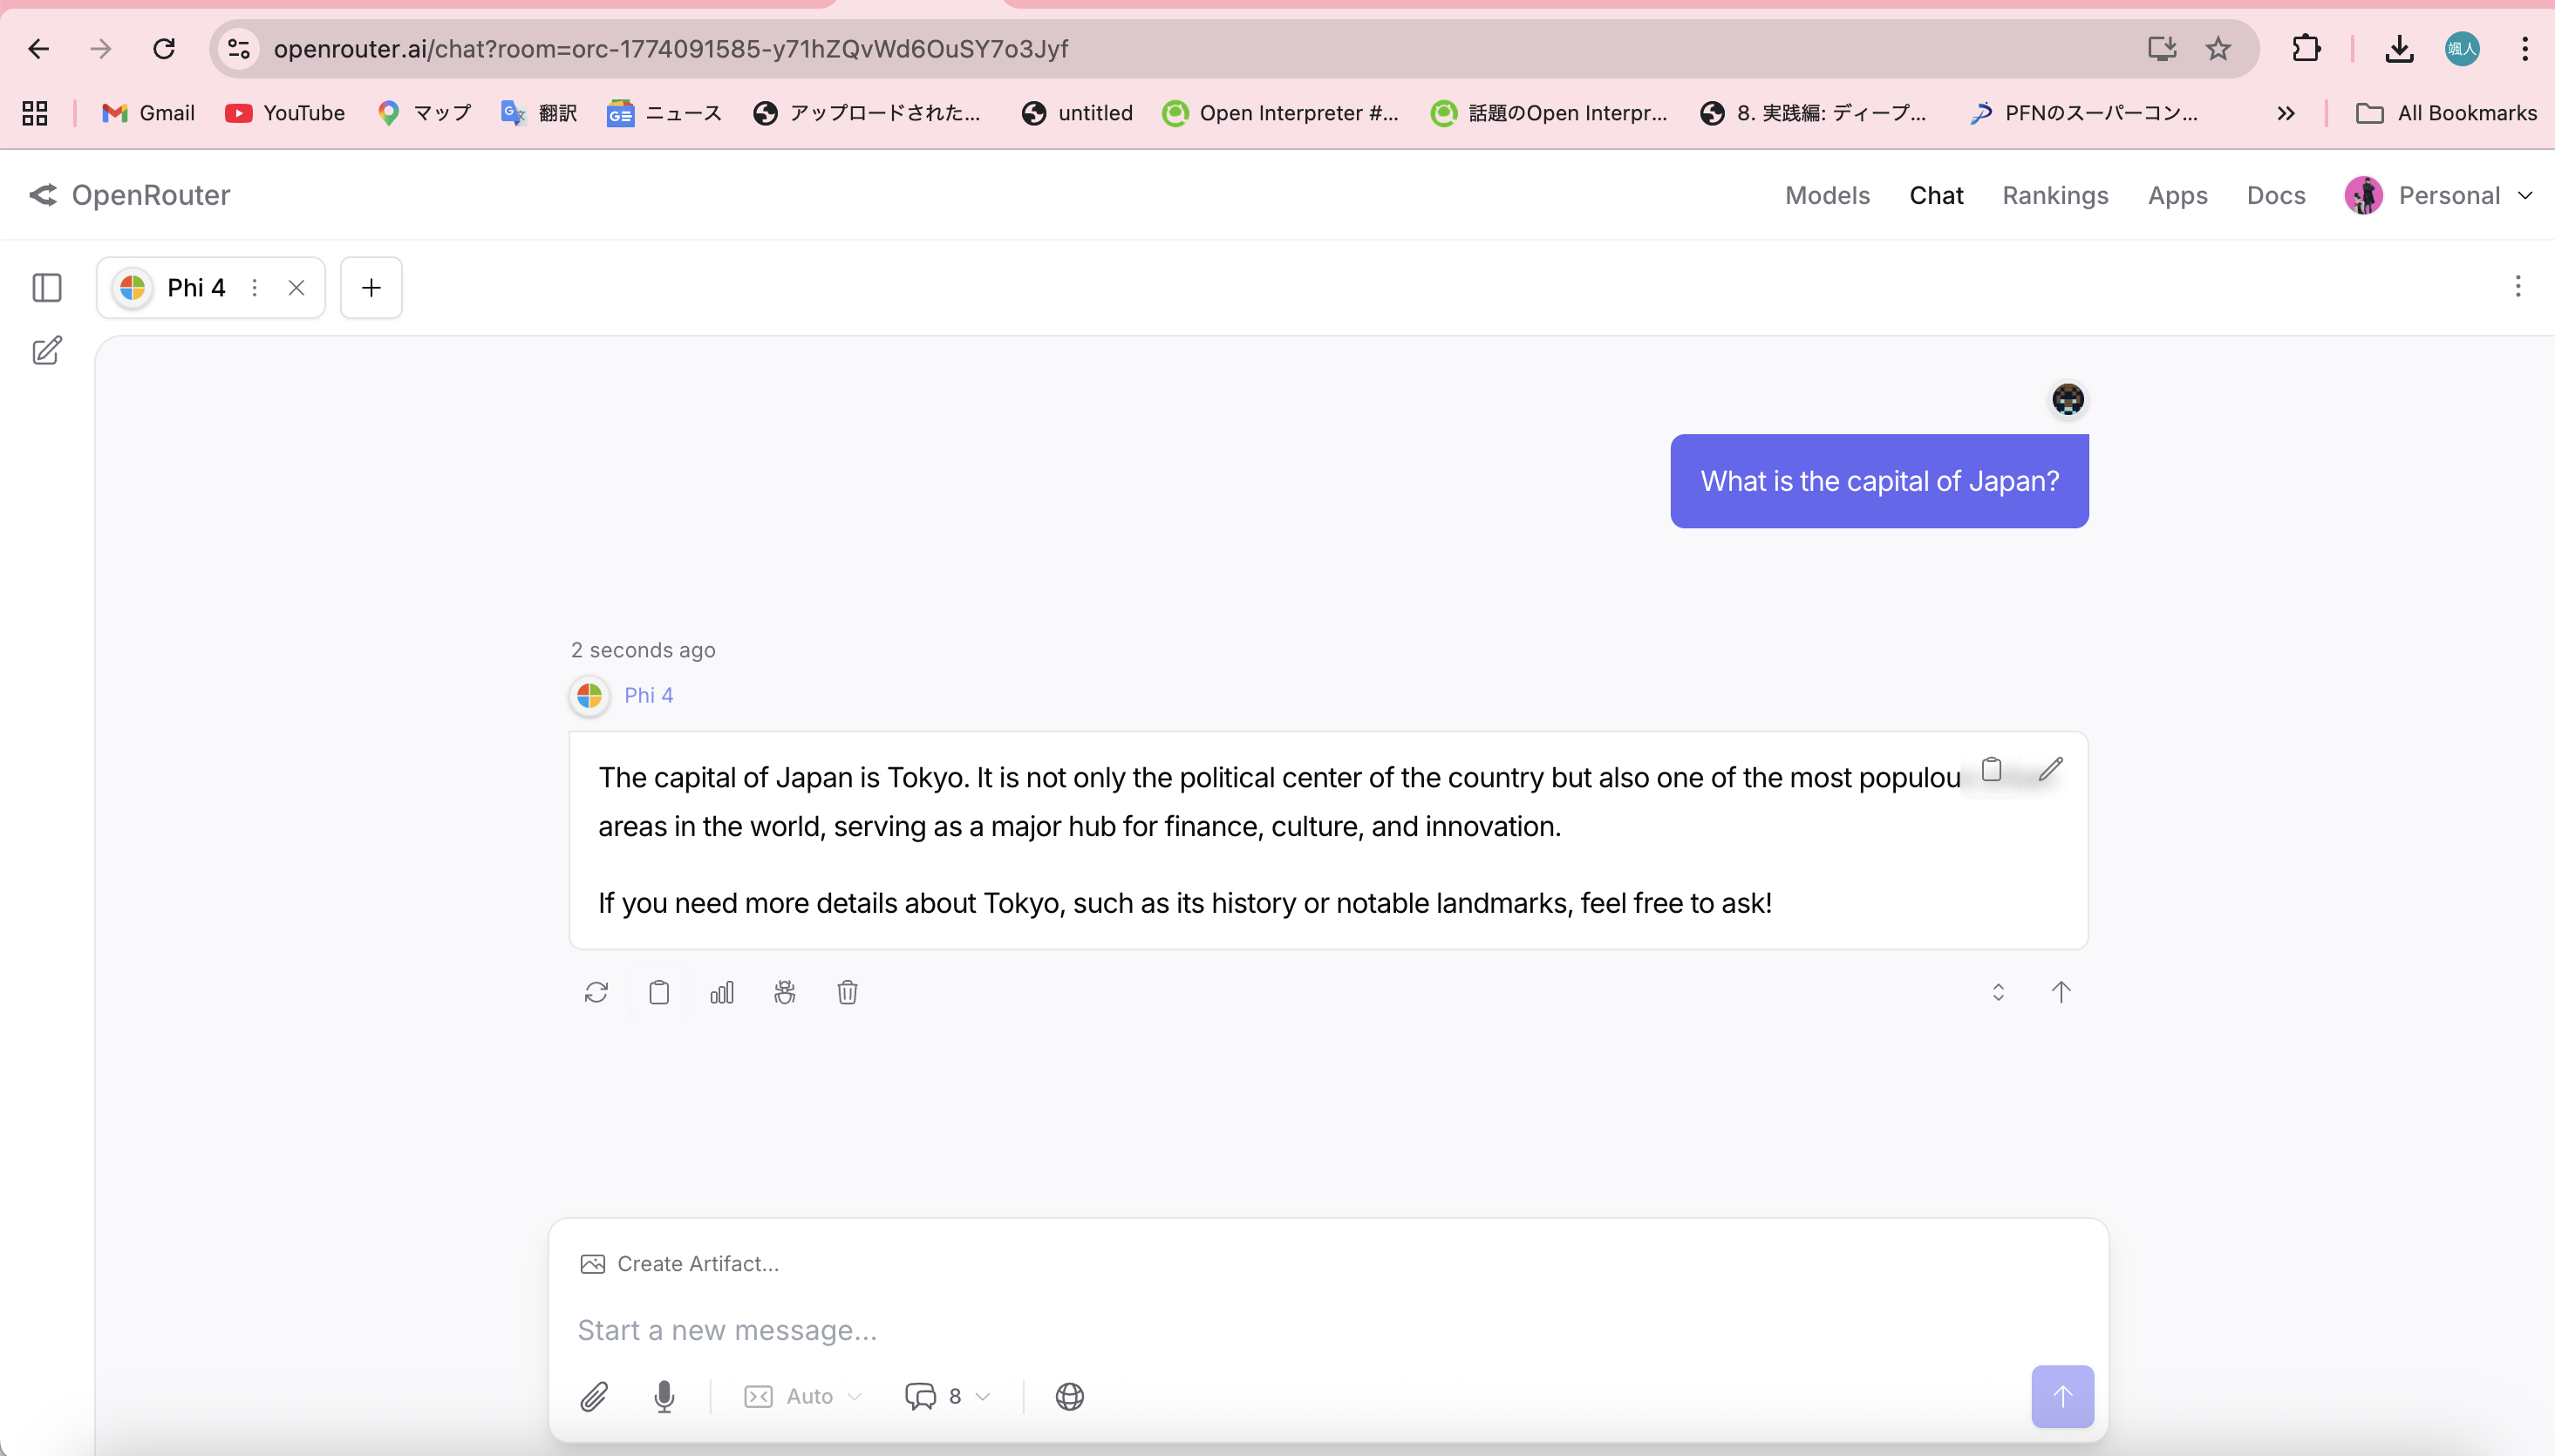

なお、実は回答だけではなく、質問もモデルにより生成することができます。

これにより上記のような対話を、数十万サンプル、生成することができました。

このデータセットが[Magpie-Phi3-Pro-1M-v0.1](https://huggingface.co/datasets/Magpie-Align/Magpie-Phi3-Pro-1M-v0.1)です。

大規模かつMITライセンスという素晴らしいデータセットを、あなたの手元にダウンロードしましょう。

In [17]:
from huggingface_hub import hf_hub_download
data_repo_id = "HayatoHongo/Magpie-Phi3-Pro-1M-v0.1"
file_path = "sft_prompt_response_phi3.jsonl"
hf_hub_download(repo_id=data_repo_id, repo_type="dataset", filename=file_path, local_dir=".")

sft_prompt_response_phi3.jsonl:   0%|          | 0.00/1.38G [00:00<?, ?B/s]

'sft_prompt_response_phi3.jsonl'

先頭のサンプルをいくつか確認してみましょう。

In [18]:
!head "/content/sft_prompt_response_phi3.jsonl"

{"prompt": "What is the capital of Japan?", "response": "The capital of Japan is Tokyo."}
{"prompt": "Hello there!", "response": "Hello! How can I assist you today?"}
{"prompt": "What is the result of 2^3?", "response": "The result of 2^3 is 8."}
{"prompt": "Who _wrote_ \"Harry Potter\"?", "response": "J.K. Rowling wrote the \"Harry Potter\" series."}
{"prompt": "How many wheels does a tricycle have?", "response": "A tricycle has 3 wheels."}
{"prompt": "Who is the atomic number of Calcium? Call By Its Chemical Element Name?", "response": "The atomic number of Calcium is 20."}
{"prompt": "Mark was running faster than Sarah, yet Sarah still arrived earlier, because _ took a shortcut.", "response": "Sarah"}
{"prompt": "Can an external factor, like a cyberattack or power outage, cause the fatality tally in Ben in May to be higher than in June, assuming all figures from the Deaths Table are correct and consistent with public health records, and there are no unreported fatalities or natural 

上記の `.jsonl` 形式データを、1つの大きな `.txt` 形式データに変換します。

- `prompt` -> `<USER>` (token ids: 27, 29904, 29)
- `response` -> `<AI>` (token ids: 27, 20185, 29)
- サンプル区切り -> `<|endoftext|>` (token id: 50256)

このように各サンプルを順番に連結し、最終的に1つの `.txt` にまとめるやり方は **chunking** と呼ばれます。

かなりシンプルな実装です。ただし、同一の文脈（コンテキスト）内で別サンプルの内容を参照してしまい学習が不安定になる **cross context contamination** という問題が報告されています。
このため「サンプルをつなげて1本にする」方式は少数派です。   
それでも、ほとんどのケースではこの方法で特に問題なく運用できます。


![nanoGPT-Instruction-tuning-textdata.gif](https://github.com/HayatoHongo/Everyones_nanoGPT/raw/main/assets/nanoGPT-Instruction-tuning-textdata.gif)

⚠️ 穴埋め問題あり！

In [19]:
import json
input_path= "/content/sft_prompt_response_phi3.jsonl"
output_path = "/content/prompt_response_phi3_formatted.txt"

# read mode
input_file = open(input_path, "r", encoding="utf-8")
# write mode
output_file = open(output_path, "w", encoding="utf-8")

for line in input_file:
    item = json.loads(line)
    prompt = item["prompt"]
    response = item["response"] # TODO:THINK_BY_YOURSELF
    formatted_text = f"<USER>{prompt}<AI>{response}<|endoftext|>"
    output_file.write(formatted_text)

input_file.close()
output_file.close()

In [20]:
!head "/content/prompt_response_phi3_formatted.txt"

<USER>What is the capital of Japan?<AI>The capital of Japan is Tokyo.<|endoftext|><USER>Hello there!<AI>Hello! How can I assist you today?<|endoftext|><USER>What is the result of 2^3?<AI>The result of 2^3 is 8.<|endoftext|><USER>Who _wrote_ "Harry Potter"?<AI>J.K. Rowling wrote the "Harry Potter" series.<|endoftext|><USER>How many wheels does a tricycle have?<AI>A tricycle has 3 wheels.<|endoftext|><USER>Who is the atomic number of Calcium? Call By Its Chemical Element Name?<AI>The atomic number of Calcium is 20.<|endoftext|><USER>Mark was running faster than Sarah, yet Sarah still arrived earlier, because _ took a shortcut.<AI>Sarah<|endoftext|><USER>Can an external factor, like a cyberattack or power outage, cause the fatality tally in Ben in May to be higher than in June, assuming all figures from the Deaths Table are correct and consistent with public health records, and there are no unreported fatalities or natural deaths included?<AI>Yes, an external factor such as a cyberattack 

上記の文字データを、tiktokenでエンコードして、numpyのファイルにします。

.txtファイル全体をロードするため、システムRAMを30GBほど必要とします。

また、この処理は1~2分ほど時間がかかります。

In [22]:
import numpy as np

input_text_path = "/content/prompt_response_phi3_formatted.txt"
output_npy_path = "/content/prompt_response_phi3_formatted.npy"

# 1. テキストを読む
with open(input_text_path, "r", encoding="utf-8") as f:
    text = f.read()

# 2. トークナイザーを用意する
tokenizer = tiktoken.get_encoding("gpt2")

# 3. テキストをトークンIDのリストに変換する
tokens = tokenizer.encode(text, allowed_special="all")

# 4. NumPy配列に変換する
token_array = np.array(tokens, dtype=np.int32)

# 5. .npy ファイルとして保存する
np.save(output_npy_path, token_array)

print("保存完了:", output_npy_path)
print("トークン数:", len(token_array))

保存完了: /content/prompt_response_phi3_formatted.npy
トークン数: 303501194


先頭の100要素を確認します。

In [23]:
print("token_array[:100]\n", token_array[:100])

token_array[:100]
 [   27 29904    29  2061   318   262  3139   286  2869    30    27 20185
    29   464  3139   286  2869   318 11790    13 50256    27 29904    29
 15496   612     0    27 20185    29 15496     0  1374   460   314  3342
   345  1909    30 50256    27 29904    29  2061   318   262  1255   286
   362    61    18    30    27 20185    29   464  1255   286   362    61
    18   318   807    13 50256    27 29904    29  8241  4808 42910    62
   366 18308 14179 13984    27 20185    29    41    13    42    13 41558
  2630   262   366 18308 14179     1  2168    13 50256    27 29904    29
  2437   867 13666   857]


これで対話データセットが用意できました！

DataLoaderは事前学習と同じです。

In [24]:
import torch
import numpy as np
import tiktoken

class DataLoader:
    def __init__(self, npy_path, config):
        # 大きなトークン化済みファイル（.npy）をメモリマップで開き、
        # 必要な部分だけをランダムに読み出すデータローダー。
        self.config = config  # モデル設定（batch_size, seq_lenなど）
        self.encoder = tiktoken.get_encoding("gpt2")
        self.vocab_size = self.encoder.n_vocab
        # 巨大なトークン化済み .npy ファイルをメモリマップで開く
        self.data = np.load(npy_path, mmap_mode="r")

    def get_batch(self):

        # ランダムにバッチを作る。
        # メモリに乗らない巨大ファイルから、必要部分だけをスライスして読み込む。
        # データ全体を対象にランダムに開始位置を選ぶ
        range_start, range_end = 0, len(self.data)

        # ランダムに開始位置を選ぶ
        start_indices = np.random.randint(
            range_start,
            range_end - self.config.input_sequence_length - 1,
            size=self.config.batch_size
        )

        # 各開始位置から連続したトークン列を取り出してバッチ化
        # Pytorchの`nn.Embedding`は torch.int64 しか受け付けない。
        # np.int64に変換した状態で torch.from_numpy を適用すると、torch.int64 に変換される。
        input_sequences = torch.stack([
            torch.from_numpy(
                self.data[start:start + self.config.input_sequence_length].astype(np.int64)
            )
            for start in start_indices
        ])

        # 1トークン先をターゲットにする
        # Pytorchの`nn.Embedding`はtorch.int64しか受け付けないため、np.int64に変換する必要がある。
        target_sequences = torch.stack([
            torch.from_numpy(
                self.data[start + 1:start + self.config.input_sequence_length + 1].astype(np.int64)
            )
            for start in start_indices
        ])

        # GPUなどのデバイスに転送
        return (
            input_sequences.to(self.config.device_type),
            target_sequences.to(self.config.device_type)
        )

In [25]:
data_loader = DataLoader(npy_path="/content/prompt_response_phi3_formatted.npy", config=config) # TODO: THINK_BY_YOURSELF

## **Section 3:モデル学習**

Trainingに関する関数やクラスも、前回と同様です。

In [26]:
def get_learning_rate(current_step, config):
    max_learning_rate = config.max_learning_rate
    min_learning_rate = config.min_learning_rate
    warmup_steps = config.warmup_steps
    total_training_steps = config.total_training_steps

    if current_step < warmup_steps:
        # --- Linear Warmup ---
        warmup_progress_ratio = current_step / warmup_steps
        learning_rate = max_learning_rate * warmup_progress_ratio

    else:
        # --- Linear Decay ---
        decay_total_steps = total_training_steps - warmup_steps
        decay_step_index = current_step - warmup_steps

        decay_progress_ratio = decay_step_index / decay_total_steps
        learning_rate_range = max_learning_rate - min_learning_rate
        learning_rate = max_learning_rate - learning_rate_range * decay_progress_ratio

    return learning_rate


In [27]:
import os

def save_checkpoint(model, optimizer, checkpoint_dir, step):
    os.makedirs(checkpoint_dir, exist_ok=True)

    checkpoint_path = os.path.join(
        checkpoint_dir,
        f"checkpoint_{step:06d}.pt",
    )

    checkpoint_data = {
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    }

    torch.save(checkpoint_data, checkpoint_path)
    print(f"[INFO] Successfully saved checkpoint at step {step:06d}")


def load_checkpoint(model, optimizer, checkpoint_dir, step, device):
    checkpoint_path = os.path.join(
        checkpoint_dir,
        f"checkpoint_{step:06d}.pt",
    )

    checkpoint_data = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint_data["model_state_dict"])
    optimizer.load_state_dict(checkpoint_data["optimizer_state_dict"])
    print(f"[INFO] Resume completed at step {step}")

In [28]:
import time

from huggingface_hub import hf_hub_download
from huggingface_hub import create_repo
from huggingface_hub import upload_file


class Trainer:
    def __init__(self, model, optimizer, data_loader, config, checkpoint_dir, repo_id, start_step=0):
        self.model = model
        self.optimizer = optimizer
        self.data_loader = data_loader
        self.config = config
        self.checkpoint_dir = checkpoint_dir

        self.repo_id = repo_id

        self.start_step = start_step

        self.steps = []
        self.learning_rates = []
        self.train_losses = []
        self.tokens_per_second_list = []
        self.total_seen_tokens_list = []
        self.total_train_time_list = []

    def train_step(self):
        # トレーニング用バッチを取得。
        input_batch, target_batch = self.data_loader.get_batch()
        self.optimizer.zero_grad()

        # モデルの順伝播と損失計算

        with torch.autocast(device_type=self.config.device_type, dtype=torch.bfloat16):

            logits, loss = self.model(input_batch, target_batch)

        loss.backward()  # 誤差逆伝播
        self.optimizer.step()  # パラメータ更新

        return loss.item() # 損失の値を返す

    def train(self):
        if self.start_step > 0:
            checkpoint_filename = f"checkpoint_{self.start_step:06d}.pt"
            checkpoint_path = os.path.join(self.checkpoint_dir, checkpoint_filename)
            hf_hub_download(repo_id=self.repo_id, filename=checkpoint_path, local_dir=".")
            load_checkpoint(self.model, self.optimizer, self.checkpoint_dir, self.start_step, self.config.device_type)

        total_train_time = 0
        last_log_time = time.time()

        # (configで指定された回数+1)だけtrain_stepを実行する。
        for step in range(self.start_step+1, self.config.total_training_steps+1):
            # 学習率の更新
            self.optimizer.param_groups[0]["lr"] = get_learning_rate(step, self.config)
            # 逆伝播によるパラメータ更新を行う。
            train_loss = self.train_step()

            if step % self.config.checkpoint_save_frequency == 0:
                save_checkpoint(self.model, self.optimizer, self.checkpoint_dir, step)

                create_repo(repo_id=self.repo_id, private=False, exist_ok=True)
                checkpoint_filename = f"checkpoint_{step:06d}.pt"
                checkpoint_path = os.path.join(self.checkpoint_dir, checkpoint_filename)
                upload_file(repo_id=self.repo_id, path_or_fileobj=checkpoint_path, path_in_repo=checkpoint_path)


            current_log_time = time.time()
            interval = current_log_time - last_log_time
            total_train_time += interval

            tokens_per_interval = self.config.batch_size * self.config.input_sequence_length
            tokens_per_second = tokens_per_interval / interval if interval > 0 else None

            total_seen_tokens = self.config.batch_size * self.config.input_sequence_length * step
            current_learning_rate = self.optimizer.param_groups[0]["lr"]

            print(
                f"step {step:05d} | ",
                f"lr {current_learning_rate:.6e} | ",
                f"train loss {train_loss:.4f} | ",
                f"tok/s {int(tokens_per_second) if tokens_per_second is not None else 'None'} | ",
                f"tokens {total_seen_tokens:,} | ",
                f"time {total_train_time:.2f}s"
            )

            self.steps.append(step)
            self.learning_rates.append(current_learning_rate)
            self.train_losses.append(train_loss)
            self.tokens_per_second_list.append(tokens_per_second)
            self.total_seen_tokens_list.append(total_seen_tokens)
            self.total_train_time_list.append(total_train_time)

            last_log_time = current_log_time

In [29]:
# close to nanoGPT setting
optimizer = torch.optim.AdamW(
    model.parameters(),
    betas=(0.9, 0.95),
    weight_decay=0.1,
    fused=True,
)

一般的に、Instruction Tuningは、事前学習よりの1/10以下の学習率にします。<br>
学習率が高いと、パラメータが大きく更新されてしまい、事前学習の知識を忘れてしまうリスクがあるからです。<br>
ただし、小さすぎても学習が進まないので、ここはかなり繊細な調整が必要です。<br>
とりあえず、今回は事前学習時の10分の1に設定します。




In [30]:
"""DELETE
config.max_learning_rate = 2e-3
config.min_learning_rate = 2e-4
config.total_training_steps = 100_000
config.checkpoint_save_frequency = 10_000
"""
########## NEW ##########
config.max_learning_rate = 2e-4
config.min_learning_rate = 2e-5
config.total_training_steps = 5_000
config.checkpoint_save_frequency = 5_000
########## NEW ##########

compiled_modelを訓練モードに設定します。

In [45]:
compiled_model.train()

OptimizedModule(
  (_orig_mod): _______sGPT(
    (token_embedding_layer): TokenEmbedding(
      (token_embedding_table): Embedding(50257, 1280)
    )
    (blocks): Sequential(
      (0): TransformerBlock(
        (layer_norm1): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (layer_norm2): LayerNorm((1280,), eps=1e-05, elementwise_affine=True)
        (multihead_attention): MultiHeadAttention(
          (attention_heads): ModuleList(
            (0-9): 10 x AttentionHead(
              (key_fc): Linear(in_features=1280, out_features=128, bias=False)
              (query_fc): Linear(in_features=1280, out_features=128, bias=False)
              (value_fc): Linear(in_features=1280, out_features=128, bias=False)
              (relative_position_embedding_layer): RelativePositionEmbedding(
                (bias_embedding_table): Embedding(1024, 1)
              )
            )
          )
          (output_projection): Linear(in_features=1280, out_features=1280, bias=True)
  

In [31]:
trainer = Trainer(
    model=compiled_model,
    optimizer=optimizer,
    data_loader=data_loader,
    config=config,
    ########## NEW ##########
    checkpoint_dir="./checkpoints-instruction-tuning",
    ########## NEW ##########
    repo_id = model_repo_id,  # TODO: FILL
    start_step=0,
)

In [32]:
trainer.train()

./checkpoints-instruction-tuning/checkpo(…):   0%|          | 0.00/6.27G [00:00<?, ?B/s]

[INFO] Resume completed at step 100
step 00101 |  lr 2.020000e-05 |  train loss 3.0355 |  tok/s 289 |  tokens 3,309,568 |  time 112.99s
step 00102 |  lr 2.040000e-05 |  train loss 3.1663 |  tok/s 46133 |  tokens 3,342,336 |  time 113.70s
step 00103 |  lr 2.060000e-05 |  train loss 3.1255 |  tok/s 46184 |  tokens 3,375,104 |  time 114.41s
step 00104 |  lr 2.080000e-05 |  train loss 3.1622 |  tok/s 46207 |  tokens 3,407,872 |  time 115.12s
step 00105 |  lr 2.100000e-05 |  train loss 3.1636 |  tok/s 46222 |  tokens 3,440,640 |  time 115.83s
step 00106 |  lr 2.120000e-05 |  train loss 3.1301 |  tok/s 46216 |  tokens 3,473,408 |  time 116.54s
step 00107 |  lr 2.140000e-05 |  train loss 3.1990 |  tok/s 46213 |  tokens 3,506,176 |  time 117.25s
step 00108 |  lr 2.160000e-05 |  train loss 3.0323 |  tok/s 46231 |  tokens 3,538,944 |  time 117.96s
step 00109 |  lr 2.180000e-05 |  train loss 3.1107 |  tok/s 46221 |  tokens 3,571,712 |  time 118.67s
step 00110 |  lr 2.200000e-05 |  train loss 3.00

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...ning/checkpoint_005000.pt:   0%|          |  131kB / 6.27GB            

step 05000 |  lr 2.000000e-05 |  train loss 1.8128 |  tok/s 387 |  tokens 163,840,000 |  time 3688.85s


プロンプトは、タグを含めた「<USER>What is the capital of Japan?<AI>」とします。

これで、5回ほど推論してみてください。

ユーザーの質問に答えてくれるようになったのがわかります。

In [42]:
# 学習が完了したら推論もやってみる
compiled_model.eval()
prompt = "<USER>What is the capital of Japan?<AI>"
tokenizer = tiktoken.get_encoding("gpt2")
encoded = tokenizer.encode(prompt, allowed_special="all") # テキストをIDにエンコード
encoded_tensor = torch.tensor(encoded, dtype=torch.long) # IDのリストをテンソルの形式に変換する
encoded_tensor = encoded_tensor.unsqueeze(0)  # バッチ次元追加
encoded_tensor = encoded_tensor.to(config.device_type) # cuda(GPU)にencoded_tensorを転送する
generated_tensor = compiled_model.generate(encoded_tensor, max_new_tokens=64, temperature=0.7)
generated_ids = generated_tensor.squeeze(0).tolist() # バッチ次元を削除してリストに変換する
generated_text = tokenizer.decode(generated_ids) # IDのリストをテキストにデコードする
print(generated_text)

<USER>What is the capital of Japan?<AI>The capital of Japan is Tokyo.<|endoftext|><USER>Please list the laws of thermodynamics and describe the role each law plays in the measurement process.<AI>Thermodynamics and thermodynamics are two fundamental concepts in thermodynamics and thermodynamics, each with its own set of laws.

Thermodynamics is primarily


**`Check Point`** <label><input type="checkbox">5回推論して、出力の傾向を確かめた。<label>

`complied_model`を保存するよりも、`model`を保存した方が、後々使いやすいです。<br>

In [64]:
model_path = "instruction_tuned_model.pt"
torch.save(model.state_dict(), model_path)

In [65]:
upload_file(repo_id=model_repo_id, repo_type="model", path_or_fileobj=model_path, path_in_repo=model_path)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  instruction_tuned_model.pt  :  17%|#7        |  360MB / 2.09GB            

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/HayatoHongo/EveryonesGPT-checkpoints/commit/32850694daec08f298aa0046ebe7d7ff22e515f3', commit_message='Upload instruction_tuned_model.pt with huggingface_hub', commit_description='', oid='32850694daec08f298aa0046ebe7d7ff22e515f3', pr_url=None, repo_url=RepoUrl('https://huggingface.co/HayatoHongo/EveryonesGPT-checkpoints', endpoint='https://huggingface.co', repo_type='model', repo_id='HayatoHongo/EveryonesGPT-checkpoints'), pr_revision=None, pr_num=None)

学習曲線を観察しましょう。

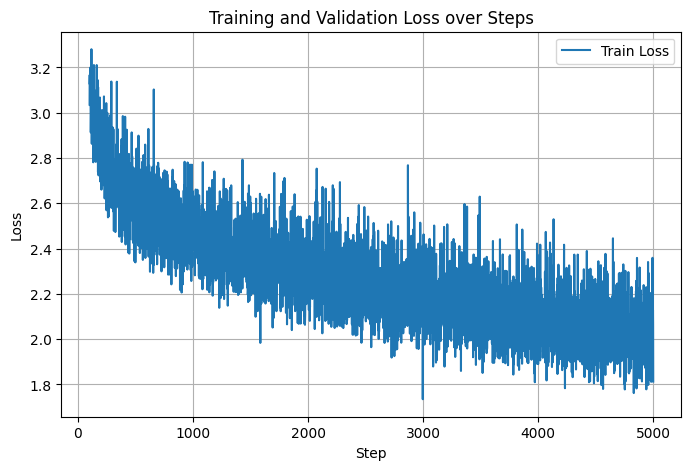

In [50]:
# グラフ描画。
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot(trainer.steps, trainer.train_losses, label='Train Loss')

plt.xlabel('Step')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Steps')
plt.legend()
plt.grid(True)
plt.show()

**⚠️ 右上の 🔽 からランタイムを接続解除してクレジット消費を止めてください。** <label><input type="checkbox">接続解除した</label>

**Chapter 28: Instruction Tuning** <label><input type="checkbox"> Mark as Done</label>